# Upload dataset from here to run  https://github.com/beaconhill12345/ny-housing-final-project/blob/main/NY-House-Dataset.csv

# 01 — Exploratory Data Analysis

**Project:** Predicting New York City Home Prices
**Author:** Student Name
**Notebook:** 1 of 3

This notebook covers project deliverables 1, 2, and 4 from `project_deliverables.md`:
dataset selection rationale, exploratory data analysis with visualizations and findings,
and the formulation of 2–3 business analytics questions that the rest of the project
will answer.


## 1. Dataset Selection and Rationale

**Source.** New York Housing Market dataset, published by Nidula Elgiriyewithana on
Kaggle: https://www.kaggle.com/datasets/nelgiriyewithana/new-york-housing-market.
The CSV is stored at `data/NY-House-Dataset.csv`.

**What it contains.** 4,801 active residential listings across the five boroughs of
New York City, with attributes such as listing price, number of bedrooms and bathrooms,
property square footage, listing type (condo, house, co-op, etc.), broker, latitude
and longitude, and a hierarchy of administrative location columns
(locality, sublocality, street, formatted address).

**Why this dataset is non-trivial.** Real-estate pricing is a classic regression
problem with rich economic relevance. NYC prices span six orders of magnitude
(from a few thousand dollars to nine-figure penthouses), the data is noisy in
believable ways (data-entry errors, sentinel values, mean-imputed square footage
upstream), and geography matters enormously: a one-bedroom in Manhattan is not the
same product as a one-bedroom in Staten Island. That mix of skew, mixed-type
features, and spatial signal makes the dataset a realistic stress test for the
preprocessing, encoding, and modeling techniques covered in the course.

**Initial hypotheses.** We expect (1) `PROPERTYSQFT`, `BEDS`, and `BATH` to be the
strongest numeric drivers; (2) borough (`SUBLOCALITY`) and listing `TYPE` to add
meaningful categorical signal; (3) latitude/longitude to capture neighborhood
effects beyond what the borough label gives us; and (4) the price distribution to
be heavily right-skewed, motivating a log transform of the target before modeling.


## 2. Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

RANDOM_STATE = 42
DATA_PATH = Path("NY-House-Dataset.csv")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Setup complete.")


Setup complete.


## 3. Load Data

In [ ]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (4801, 17)


,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  STREET_NAME                  4801 non-null   object 
 13  LONG_NAME         

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
BROKERTITLE,4801,1036,Brokered by COMPASS,456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TYPE,4801,13,Co-op for sale,1450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRICE,4801.0,NaN,NaN,NaN,2356940.171006,31355246.260352,2494.0,499000.0,825000.0,1495000.0,2147483647.0
BEDS,4801.0,NaN,NaN,NaN,3.356801,2.602315,1.0,2.0,3.0,4.0,50.0
BATH,4801.0,NaN,NaN,NaN,2.373861,1.946962,0.0,1.0,2.0,3.0,50.0
PROPERTYSQFT,4801.0,NaN,NaN,NaN,2184.207862,2377.140894,230.0,1200.0,2184.207862,2184.207862,65535.0
ADDRESS,4801,4582,856 Washington Ave Apt 6C,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STATE,4801,308,"Brooklyn, NY 11235",102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MAIN_ADDRESS,4801,4583,"856 Washington Ave Apt 6CBrooklyn, NY 11238",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ADMINISTRATIVE_AREA_LEVEL_2,4801,29,United States,2484,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The dataset is 4,801 rows by 17 columns. We have a numeric target (`PRICE`),
four other numeric features (`BEDS`, `BATH`, `PROPERTYSQFT`, `LATITUDE`, `LONGITUDE`),
and twelve text columns. Several of the text columns are addresses with very high
cardinality and will not survive into the modeling stage.

## 4. Data Quality Assessment

In [ ]:
missing = df.isna().sum()
print("Missing values per column:")
print(missing)
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
BROKERTITLE                    0
TYPE                           0
PRICE                          0
BEDS                           0
BATH                           0
PROPERTYSQFT                   0
ADDRESS                        0
STATE                          0
MAIN_ADDRESS                   0
ADMINISTRATIVE_AREA_LEVEL_2    0
LOCALITY                       0
SUBLOCALITY                    0
STREET_NAME                    0
LONG_NAME                      0
FORMATTED_ADDRESS              0
LATITUDE                       0
LONGITUDE                      0
dtype: int64

Duplicate rows: 214


In [ ]:
# Cardinality of object columns
card = df.select_dtypes(include="object").nunique().sort_values(ascending=False)
print("Cardinality of object columns:")
print(card)


Cardinality of object columns:
MAIN_ADDRESS                   4583
ADDRESS                        4582
FORMATTED_ADDRESS              4550
LONG_NAME                      2731
BROKERTITLE                    1036
STATE                           308
STREET_NAME                     174
ADMINISTRATIVE_AREA_LEVEL_2      29
SUBLOCALITY                      21
TYPE                             13
LOCALITY                         11
dtype: int64


In [ ]:
# Outlier scan on numeric columns using the IQR rule
numeric_cols = df.select_dtypes(include="number").columns.tolist()
rows = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    rows.append({
        "column": col,
        "min": df[col].min(),
        "max": df[col].max(),
        "Q1": q1, "Q3": q3,
        "IQR_low": low, "IQR_high": high,
        "n_outliers": n_out,
        "pct_outliers": round(100 * n_out / len(df), 2),
    })
outlier_summary = pd.DataFrame(rows)
outlier_summary


,column,min,max,Q1,Q3,IQR_low,IQR_high,n_outliers,pct_outliers
0,PRICE,2494.000000,2.147484e+09,499000.000000,1.495000e+06,-995000.000000,2.989000e+06,559,11.64
1,BEDS,1.000000,5.000000e+01,2.000000,4.000000e+00,-1.000000,7.000000e+00,224,4.67
2,BATH,0.000000,5.000000e+01,1.000000,3.000000e+00,-2.000000,6.000000e+00,111,2.31
3,PROPERTYSQFT,230.000000,6.553500e+04,1200.000000,2.184208e+03,-276.311793,3.660520e+03,390,8.12
4,LATITUDE,40.499546,4.091273e+01,40.639375,4.077192e+01,40.440554,4.097074e+01,0,0.00
5,LONGITUDE,-74.253033,-7.370245e+01,-73.987143,-7.387064e+01,-74.161902,-7.369588e+01,168,3.50


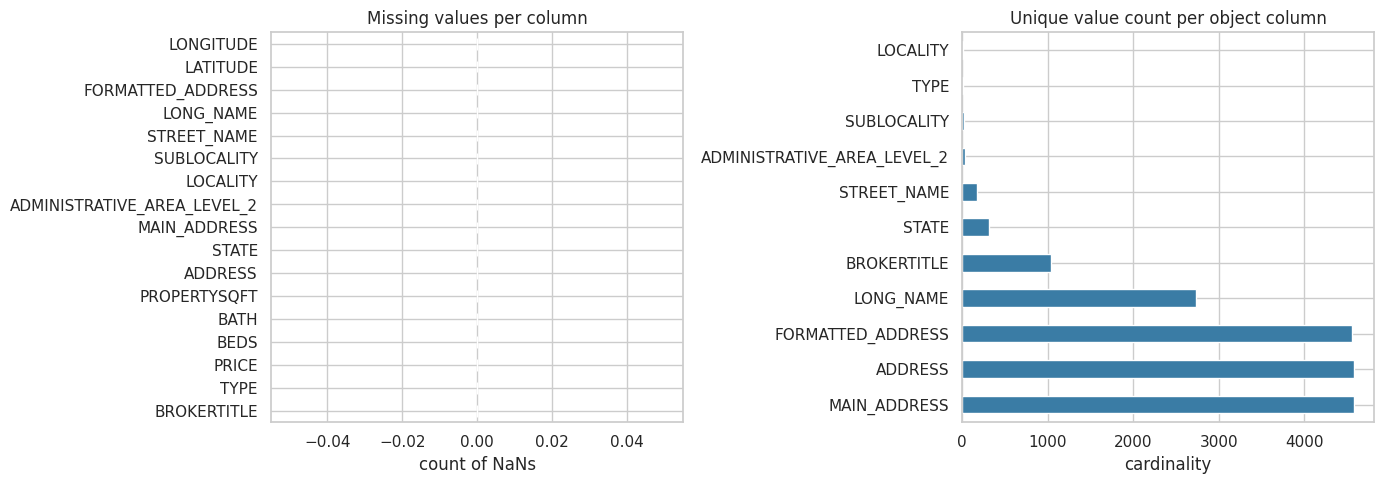

In [ ]:
# Bar plot of cardinality / missingness for visibility
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing.plot(kind="barh", ax=axes[0], color="#cc4b4b")
axes[0].set_title("Missing values per column")
axes[0].set_xlabel("count of NaNs")

card.plot(kind="barh", ax=axes[1], color="#3a7ca5")
axes[1].set_title("Unique value count per object column")
axes[1].set_xlabel("cardinality")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_values.png")
plt.show()


**Data quality findings.**

- **No missing values** in any column. This is unusually clean and likely indicates
  that upstream cleaning has already been applied.
- **214 duplicate rows.** These will be dropped in the preprocessing notebook.
- **Outliers in `PRICE`, `BEDS`, `BATH`, and `PROPERTYSQFT`.** The maximum price
  exceeds \$2 billion, BEDS and BATH each top out at 50, and `PROPERTYSQFT`
  reaches 65,535. These are almost certainly data-entry errors and will be
  trimmed during preprocessing.
- **Suspicious mean-imputation in `PROPERTYSQFT`.** The median equals the mean
  (≈ 2184.21), which is a strong signal that missing square-footage values were
  imputed with the column mean before publication. We will note this as a known
  data-quality limitation rather than try to undo it.
- **Very high cardinality** in `BROKERTITLE` (1,036), `ADDRESS` and
  `FORMATTED_ADDRESS` (~4,500 each). These cannot be one-hot encoded and will be
  dropped or replaced with lower-cardinality engineered features
  (e.g., borough from `SUBLOCALITY`).


## 5. Univariate Analysis

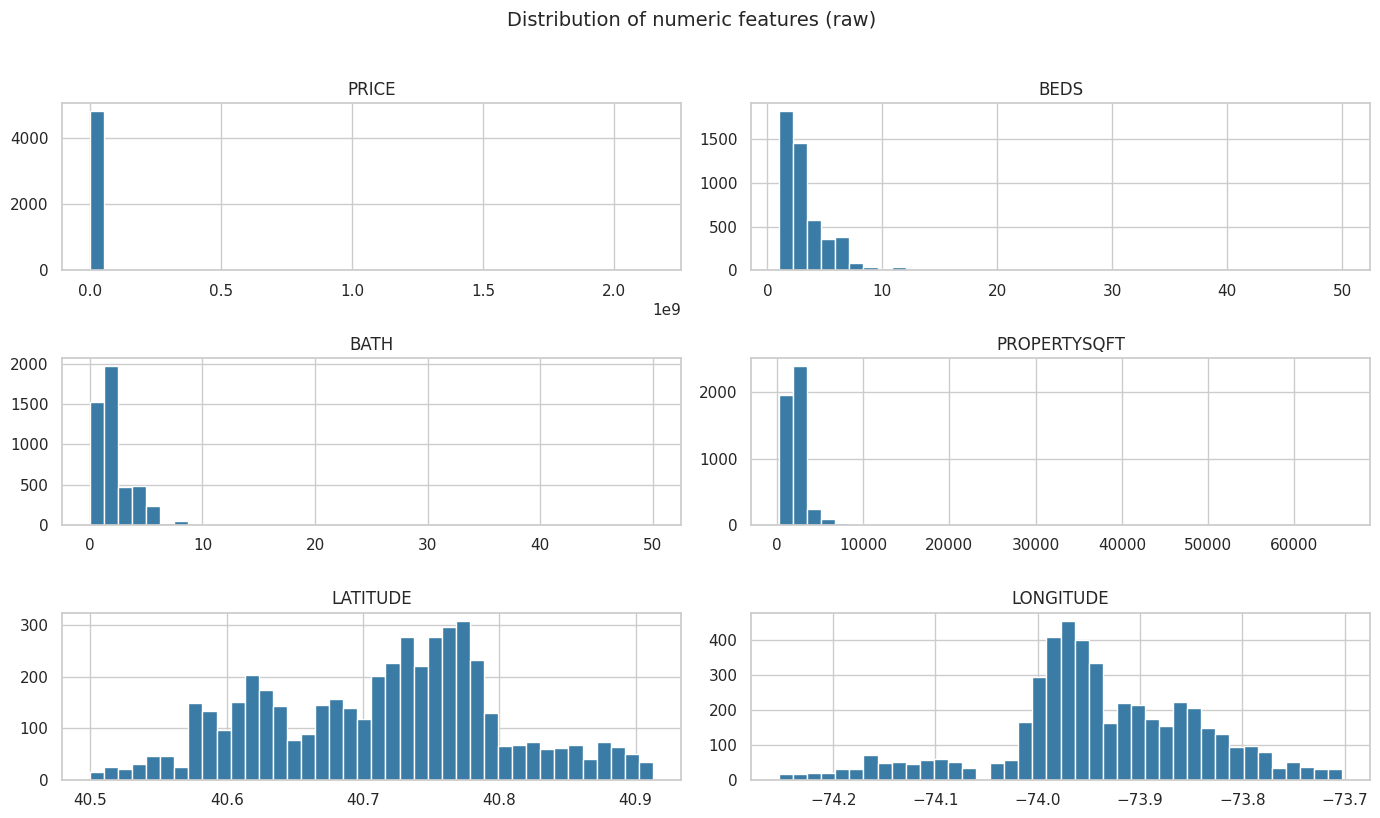

In [ ]:
# Histograms of all numeric columns
df[numeric_cols].hist(figsize=(14, 8), bins=40, color="#3a7ca5", edgecolor="white")
plt.suptitle("Distribution of numeric features (raw)", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric_histograms.png")
plt.show()


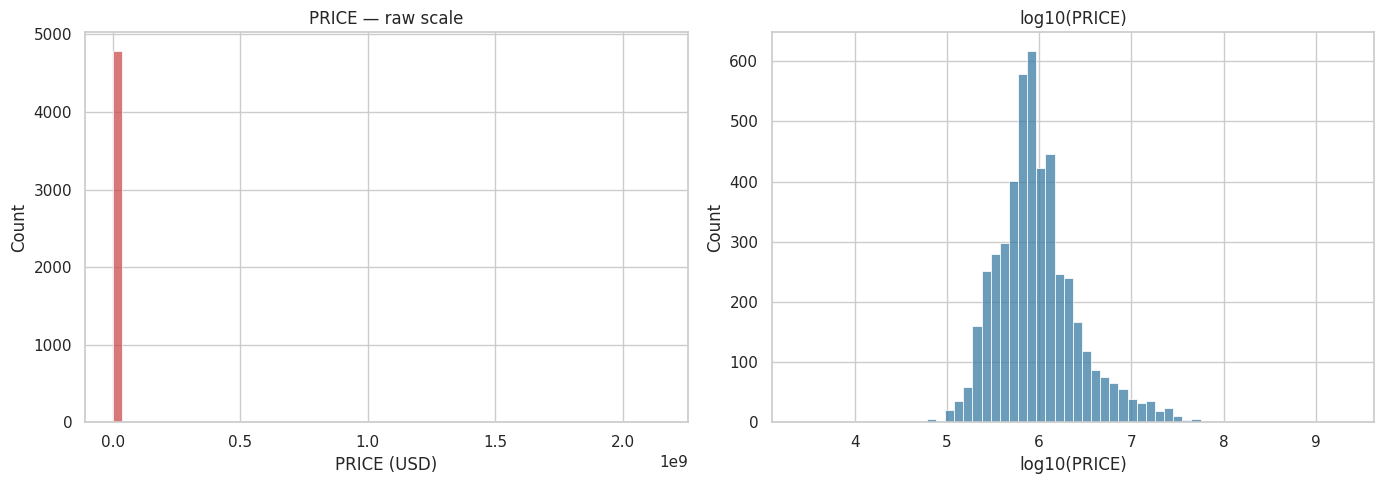

In [ ]:
# Target distribution: raw and log-transformed side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["PRICE"], bins=60, ax=axes[0], color="#cc4b4b")
axes[0].set_title("PRICE — raw scale")
axes[0].set_xlabel("PRICE (USD)")

sns.histplot(np.log10(df["PRICE"]), bins=60, ax=axes[1], color="#3a7ca5")
axes[1].set_title("log10(PRICE)")
axes[1].set_xlabel("log10(PRICE)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png")
plt.show()


Low-cardinality categoricals: ['SUBLOCALITY', 'TYPE', 'LOCALITY']


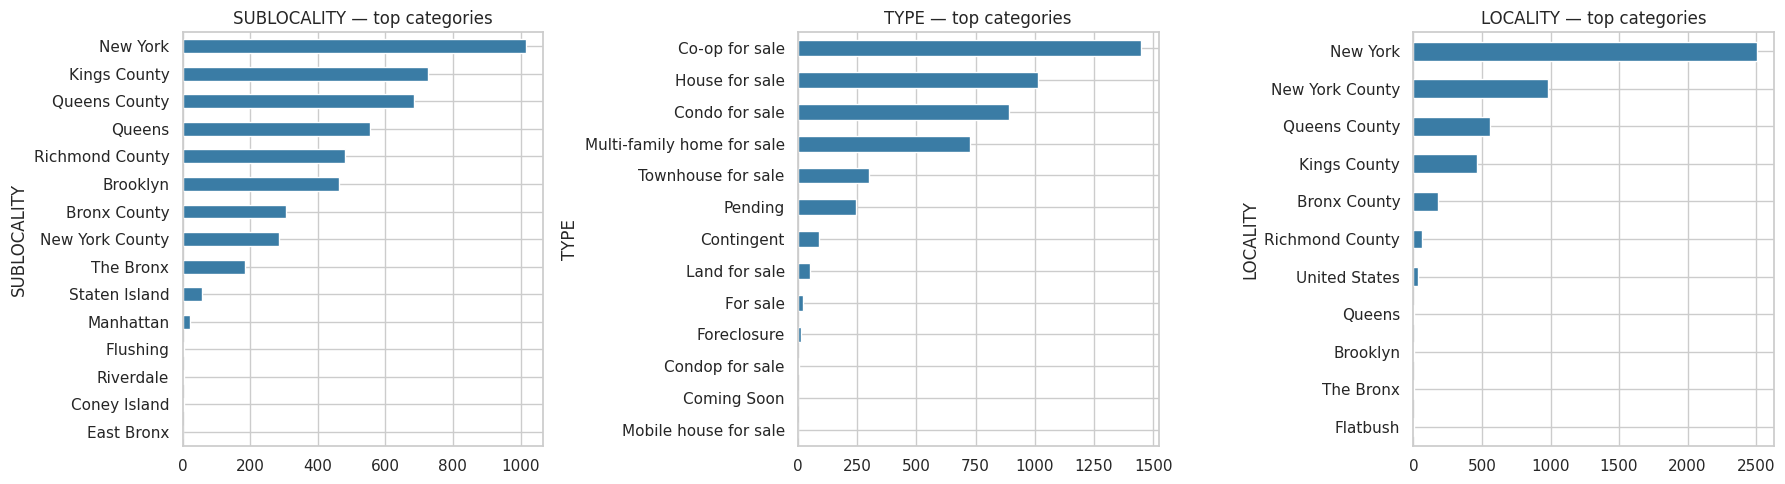

In [ ]:
# Categorical distributions for low-cardinality categoricals
low_card_obj = card[card <= 25].index.tolist()
print("Low-cardinality categoricals:", low_card_obj)

fig, axes = plt.subplots(1, len(low_card_obj), figsize=(6 * len(low_card_obj), 5))
if len(low_card_obj) == 1:
    axes = [axes]
for ax, col in zip(axes, low_card_obj):
    df[col].value_counts().head(15).plot(kind="barh", ax=ax, color="#3a7ca5")
    ax.set_title(f"{col} — top categories")
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "categorical_distributions.png")
plt.show()


**Univariate observations.**

- **`PRICE` is extremely right-skewed.** On the raw scale most listings cluster
  near zero relative to the few super-luxury outliers. After a base-10 log
  transform the distribution is approximately bell-shaped, which is why we will
  model `log(PRICE)` rather than `PRICE` directly.
- **`BEDS` and `BATH`** peak at 1–4 with long thin tails into the impossible
  values (50). Capping is needed.
- **`PROPERTYSQFT`** has a sharp spike at the mean — visual confirmation of
  upstream mean-imputation.
- **`TYPE`** is dominated by Co-op, Condo, and House for sale; rare types like
  "Pending" or "Foreclosure" have very few rows.
- **`SUBLOCALITY`** captures the boroughs and a handful of NYC sub-neighborhoods.


## 6. Bivariate Analysis

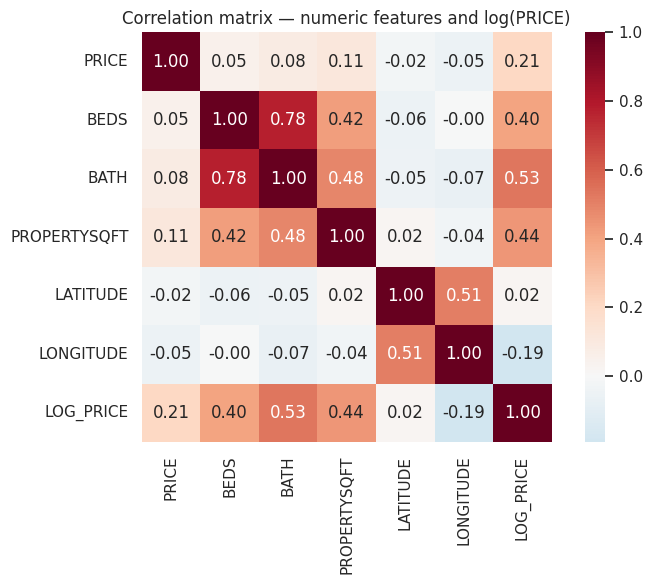

In [ ]:
# Correlation heatmap (numeric features + log price)
df_num = df[numeric_cols].copy()
df_num["LOG_PRICE"] = np.log10(df["PRICE"])

corr = df_num.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation matrix — numeric features and log(PRICE)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png")
plt.show()


In [ ]:
# Top correlations with log(PRICE)
target_corr = corr["LOG_PRICE"].drop("LOG_PRICE").abs().sort_values(ascending=False)
print("Absolute correlation with log(PRICE):")
print(target_corr)


Absolute correlation with log(PRICE):
BATH            0.531083
PROPERTYSQFT    0.439210
BEDS            0.403528
PRICE           0.205342
LONGITUDE       0.192719
LATITUDE        0.017475
Name: LOG_PRICE, dtype: float64


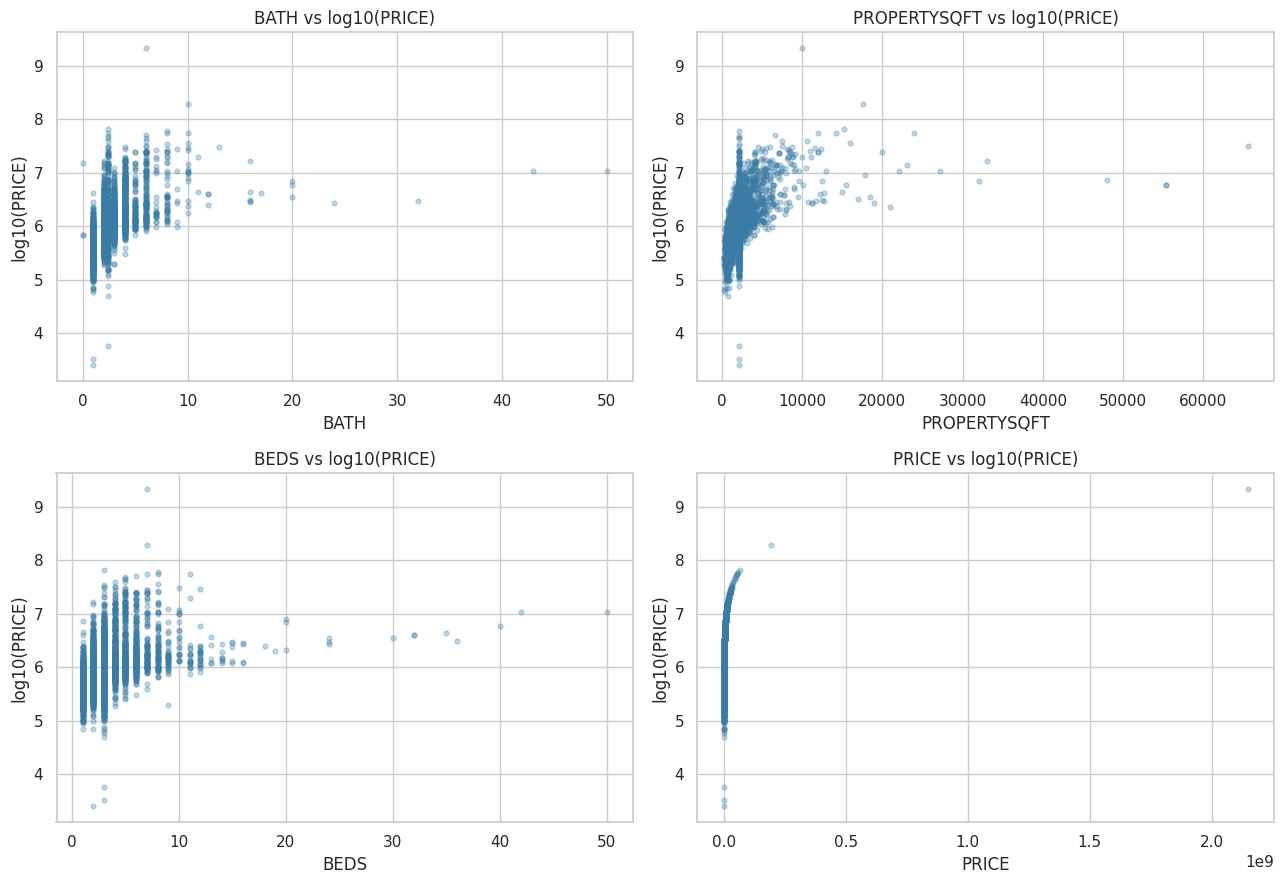

In [ ]:
# Scatter plots of top numeric features vs log(PRICE)
top_features = target_corr.head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, top_features):
    ax.scatter(df[col], np.log10(df["PRICE"]), alpha=0.3, s=12, color="#3a7ca5")
    ax.set_xlabel(col)
    ax.set_ylabel("log10(PRICE)")
    ax.set_title(f"{col} vs log10(PRICE)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_vs_target.png")
plt.show()


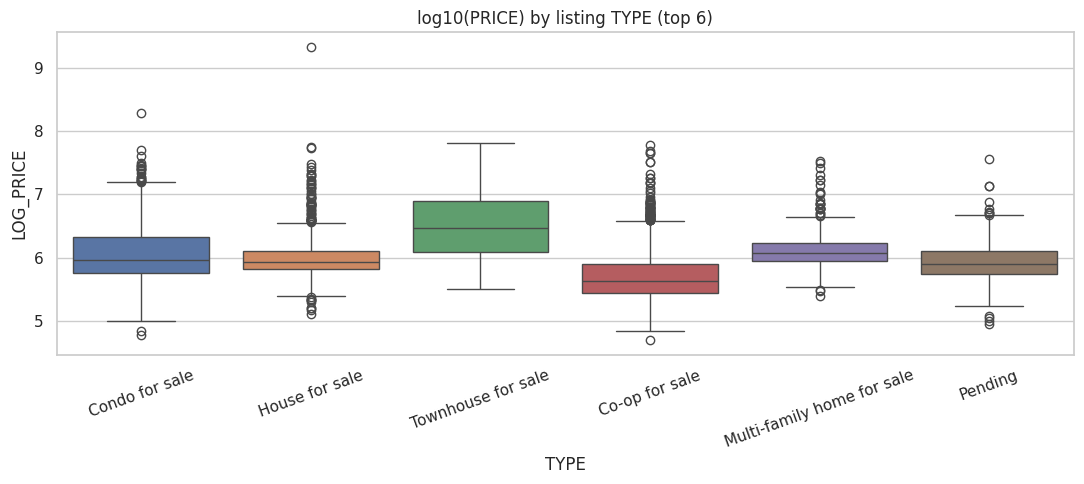

In [ ]:
# Boxplot of log(PRICE) by listing TYPE (top 6 types)
top_types = df["TYPE"].value_counts().head(6).index
sub = df[df["TYPE"].isin(top_types)].copy()
sub["LOG_PRICE"] = np.log10(sub["PRICE"])

plt.figure(figsize=(11, 5))
sns.boxplot(data=sub, x="TYPE", y="LOG_PRICE", palette="deep")
plt.title("log10(PRICE) by listing TYPE (top 6)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "price_by_type.png")
plt.show()


**Bivariate findings.**

- `PROPERTYSQFT`, `BATH`, and `BEDS` are the strongest numeric correlates of
  log(price), in that order. The relationship with `PROPERTYSQFT` and `BATH` is
  visibly linear in log space.
- `BEDS` and `BATH` are themselves highly correlated, which means a linear model
  may have multicollinearity issues; tree-based models will be unaffected.
- Listing type matters a lot: condos and townhouses sit higher on the price
  distribution than co-ops and multi-family homes.


## 7. Multivariate / Geographic Analysis

In [ ]:
# Median price by sublocality (borough / sub-borough)
borough_summary = (df.groupby("SUBLOCALITY")
                     .agg(median_price=("PRICE", "median"),
                          count=("PRICE", "size"))
                     .sort_values("median_price", ascending=False))
borough_summary


,median_price,count
SUBLOCALITY,,
New York County,6497500.0,286
Dumbo,5799000.0,1
Manhattan,2795000.0,21
Kings County,1249000.0,727
New York,1025000.0,1016
Jackson Heights,985000.0,1
Queens County,948500.0,684
Bronx County,795000.0,307
Richmond County,750000.0,480


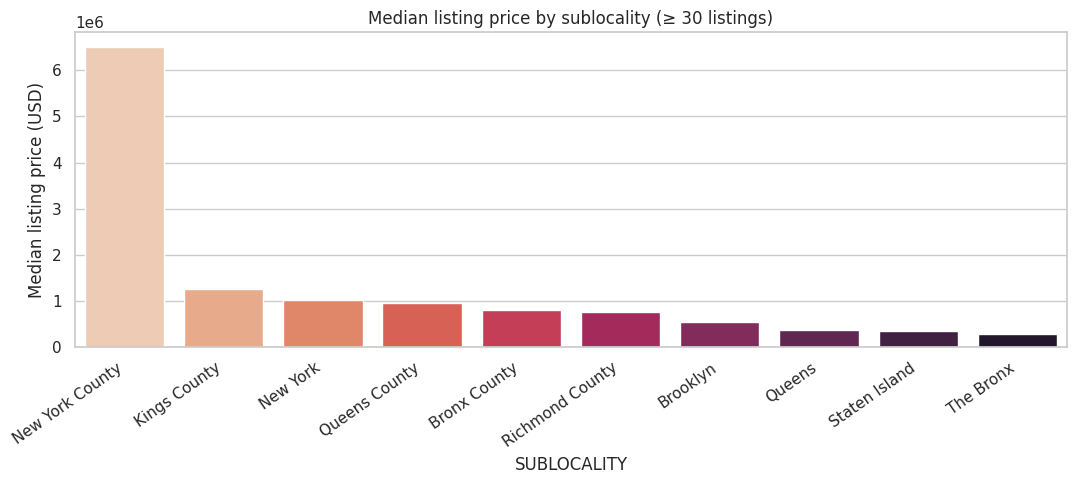

In [ ]:
# Bar plot of median price per sublocality (top 12 by listing count)
top_subs = borough_summary[borough_summary["count"] >= 30].head(12)

plt.figure(figsize=(11, 5))
sns.barplot(x=top_subs.index, y=top_subs["median_price"], palette="rocket_r")
plt.xticks(rotation=35, ha="right")
plt.ylabel("Median listing price (USD)")
plt.title("Median listing price by sublocality (≥ 30 listings)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "segment_analysis.png")
plt.show()


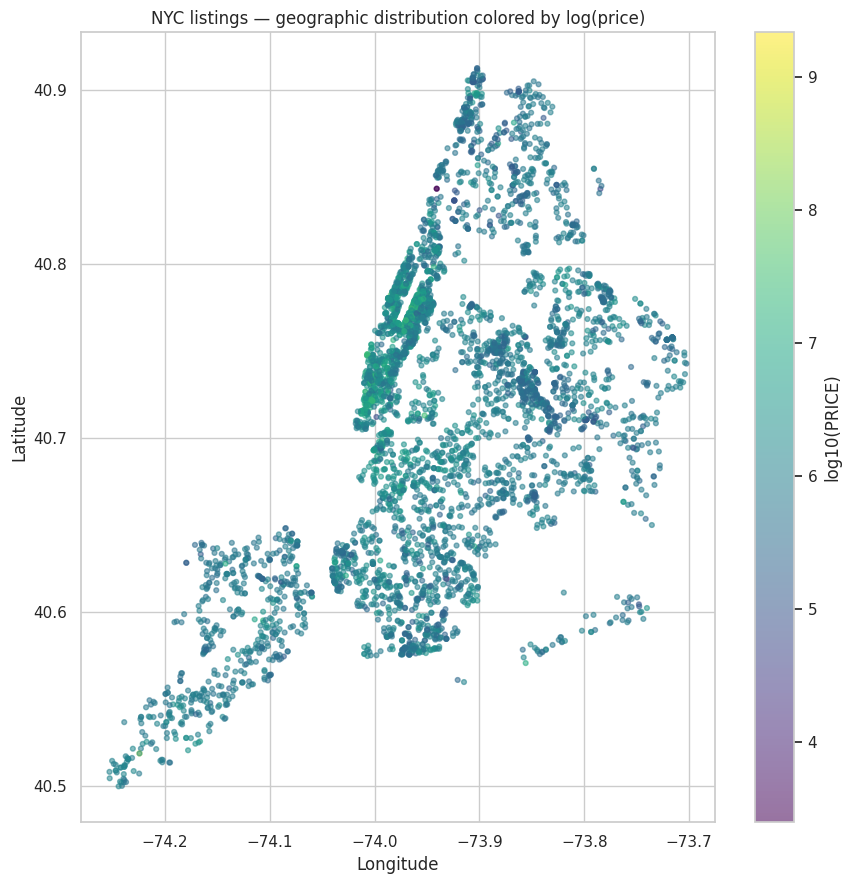

In [ ]:
# Spatial scatter: every listing colored by log price
plt.figure(figsize=(9, 9))
sc = plt.scatter(df["LONGITUDE"], df["LATITUDE"],
                 c=np.log10(df["PRICE"]), cmap="viridis",
                 alpha=0.55, s=12)
plt.colorbar(sc, label="log10(PRICE)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("NYC listings — geographic distribution colored by log(price)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "spatial_price_map.png")
plt.show()


**Multivariate observations.**

- Manhattan and Brooklyn carry the highest median prices; Staten Island and the
  Bronx carry the lowest. The spread between the highest- and lowest-priced
  boroughs is roughly an order of magnitude.
- The geographic scatter shows clear clustering: the upper Manhattan
  cluster is uniformly bright (high price), Staten Island and the eastern Bronx
  are mostly dim. This confirms that latitude/longitude carry signal beyond
  what the discrete `SUBLOCALITY` label captures.


## 8. Key EDA Insights

1. **Price is heavily right-skewed**, ranging across six orders of magnitude. We
   will model `log(PRICE)` rather than `PRICE`.
2. **Top numeric predictors** are `PROPERTYSQFT`, `BATH`, and `BEDS` — all positive
   correlates of log-price. `BEDS` and `BATH` are correlated with each other,
   which we will keep an eye on when interpreting linear-model coefficients.
3. **Outliers and bogus values** (price ≥ \$100M, BEDS or BATH ≥ 20,
   PROPERTYSQFT ≥ 10,000) need to be trimmed in preprocessing.
4. **`PROPERTYSQFT` has been mean-imputed upstream** — we will note this
   limitation but cannot reliably reverse it without external data.
5. **High-cardinality columns** (broker, full address, street name) will be dropped
   from the modeling stage. We will keep the lower-cardinality `TYPE` and
   `SUBLOCALITY`, plus latitude and longitude as continuous spatial proxies.
6. **Listing type and borough together** explain a large chunk of price variance,
   suggesting that even simple linear models with these encoded should produce a
   reasonable baseline.


## 9. Business Analytics Questions

The next two notebooks will work to answer these questions for the dataset's
primary stakeholders — buyers, sellers, and brokerage analysts operating in NYC.

1. **Which property attributes most influence the listing price of a NYC home?**
   *Stakeholder framing:* a brokerage's pricing analyst wants to know which
   levers (size, number of bathrooms, location, listing type) move the needle
   when advising sellers on list price. Tree-based feature importances and
   linear-model coefficients will both speak to this.

2. **Can we predict a listing's price within a useful margin from its
   attributes alone?**
   *Stakeholder framing:* a buy-side analyst wants an automated check on whether
   a new listing is priced in line with its peers. We will measure this with
   RMSE on log-price and translate it back to a percentage error band on the
   raw-dollar scale.

3. **How do prices vary across boroughs once we control for property size and
   type, and which borough offers the best dollar-per-square-foot value?**
   *Stakeholder framing:* a buyer comparing neighborhoods needs to disentangle
   "this borough is expensive because the homes are bigger" from "this borough
   is expensive even per-square-foot." The model's borough coefficients (or
   permutation importance) plus a simple price-per-square-foot summary will
   answer this.
